In [123]:
#install data locally

import os
os.environ["KAGGLEHUB_CACHE"] = "./data"

import kagglehub

# Download latest version
path = kagglehub.dataset_download("stevezeyuzhang/rsna-pneumonia-detection-challenge")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/stevezeyuzhang/rsna-pneumonia-detection-challenge


In [124]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
 
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.optimizers import Adam
 
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')


In [125]:
# defining constants
TRAIN_IMG_DIR = "/kaggle/input/datasets/stevezeyuzhang/rsna-pneumonia-detection-challenge/rsna-pneumonia-detection-challenge/stage_2_train_images_png"  
CSV_PATH      = "/kaggle/input/datasets/stevezeyuzhang/rsna-pneumonia-detection-challenge/rsna-pneumonia-detection-challenge/stage_2_train_labels.csv"
IMG_SIZE      = (128, 128)
BATCH_SIZE    = 128
EPOCHS        = 100
LR            = 0.00001

In [126]:
df = pd.read_csv(CSV_PATH)
 
# one row per patient as each patient either has pneumonia or not
df = df.drop_duplicates("patientId").reset_index(drop=True)
 
# Filename to match  PNG filename
df["filename"] = df["patientId"] + ".png"
 
# Labels
df["Target"] = df["Target"].astype(str)
 
print(f"Total patients : {len(df)}")
print(f"Normal  (0)    : {(df['Target'] == '0').sum()}")
print(f"Pneumonia (1)  : {(df['Target'] == '1').sum()}")


# stratify keeps the same class ratio in both splits
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Target"],
    random_state=42
)
train_df = train_df.sample(frac=0.5, random_state=42)  # ADD THIS
print(f"\nTrain size : {len(train_df)}")
print(f"Val size   : {len(val_df)}")


# Augmentation only on training data
trdata = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
)
 
# Validation: only rescale, no augmentation
tsdata = ImageDataGenerator(rescale=1.0 / 255)
 
traindata = trdata.flow_from_dataframe(
    dataframe=train_df,
    directory=TRAIN_IMG_DIR,
    x_col="filename",
    y_col="Target",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
)
 
testdata = tsdata.flow_from_dataframe(
    dataframe=val_df,
    directory=TRAIN_IMG_DIR,
    x_col="filename",
    y_col="Target",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False,
)
 


Total patients : 26684
Normal  (0)    : 20672
Pneumonia (1)  : 6012

Train size : 10674
Val size   : 5337
Found 10674 validated image filenames belonging to 2 classes.
Found 5337 validated image filenames belonging to 2 classes.


In [127]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["Target"].astype(int),
)
class_weights = {0: weights[0], 1: weights[1]}
print(f"\nClass weights: {class_weights}")
 


from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')  # ADD THIS
model = Sequential()
 
# Block 1
model.add(Conv2D(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())
 
# Block 2
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())
 
# Block 3
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())
 
# Block 4
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())
 
# Block 5
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())
 
# Classifier head
model.add(Flatten())
model.add(Dense(units=4096, activation="relu"))
model.add(Dropout(0.5))                        # prevent overfitting
model.add(Dense(units=4096, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(units=1, activation="sigmoid", dtype='float32')) # binary output
 
model.summary()



Class weights: {0: np.float64(0.6422382671480145), 1: np.float64(2.2576142131979697)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_130 (Conv2D)             │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_131 (Conv2D)             │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_132 (Conv2D)             │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_133 (Conv2D)             │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_134 (Conv2D)             │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_135 (Conv2D)             │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_136 (Conv2D)             │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_137 (Conv2D)             │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_138 (Conv2D)             │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_139 (Conv2D)             │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_140 (Conv2D)             │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_141 (Conv2D)             │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_142 (Conv2D)             │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 4, 4, 512)      │         2,04

 Total params: 65,064,513 (248.20 MB)

 Trainable params: 65,061,569 (248.19 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [128]:

def f1_score(y_true, y_pred):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred = tf.cast(tf.reshape(y_pred, [-1]) > 0.5, tf.float32)
    
    true_positives = tf.reduce_sum(y_true * y_pred)
    actual_positives = tf.reduce_sum(y_true)
    predicted_positives = tf.reduce_sum(y_pred)
    
    precision = tf.math.divide_no_nan(true_positives, predicted_positives)
    recall = tf.math.divide_no_nan(true_positives, actual_positives)
    
    f1 = tf.math.divide_no_nan(2 * precision * recall, precision + recall)
    return f1

In [129]:
from keras.metrics import Recall, Precision  

opt = Adam(learning_rate=LR)

def pneumonia_recall(y_true, y_pred):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred = tf.cast(tf.reshape(y_pred, [-1]) > 0.5, tf.float32)
    true_positives = tf.reduce_sum(y_true * y_pred)
    actual_positives = tf.reduce_sum(y_true)
    recall = tf.math.divide_no_nan(true_positives, actual_positives)
    return recall

model.compile(
    optimizer=opt,
    loss="binary_crossentropy",
    metrics=["accuracy", pneumonia_recall, f1_score]
)


from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    "/kaggle/working/vgg16_pneumonia_best.keras",
    monitor="val_f1_score",
    save_best_only=True,
    mode="max",
    verbose=1,
)

early = EarlyStopping(
    monitor="val_f1_score",
    patience=20,
    mode="max",
    verbose=1,
    restore_best_weights=True,
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=0.000001,
    verbose=1,
)

In [130]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
print(traindata.class_indices)
# Should print: {'0': 0, '1': 1}
# Pneumonia should be 1

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
{'0': 0, '1': 1}


In [131]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["Target"].astype(int),
)
class_weights = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weights)  # ADD THIS PRINT
hist = model.fit(
    traindata,
    steps_per_epoch=len(traindata),
    validation_data=testdata,
    validation_steps=len(testdata),
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[checkpoint, early, reduce_lr],

)

 


Class weights: {0: np.float64(0.6422382671480145), 1: np.float64(2.2576142131979697)}
Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5860 - f1_score: 0.3710 - loss: 0.8140 - pneumonia_recall: 0.5814
Epoch 1: val_f1_score improved from None to 0.36665, saving model to /kaggle/working/vgg16_pneumonia_best.keras

Epoch 1: finished saving model to /kaggle/working/vgg16_pneumonia_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 470s 5s/step - accuracy: 0.6208 - f1_score: 0.4146 - loss: 0.7602 - pneumonia_recall: 0.6177 - val_accuracy: 0.2252 - val_f1_score: 0.3666 - val_loss: 0.7075 - val_pneumonia_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6484 - f1_score: 0.4640 - loss: 0.6950 - pneumonia_recall: 0.6883
Epoch 2: val_f1_score did not improve from 0.36665
84/84 ━━━━━━━━━━━━━━━━━━━━ 448s 5s/step - accuracy: 0.6617 - f1_score: 0.4644 - loss: 0.6848 - pneumonia_recall: 0.6705 - val_accuracy: 0.7748 - val_f1_score: 0.0000e+00

In [138]:
testdata.reset()
preds = model.predict(testdata)

predicted_classes = (preds > 0.5).astype(int).flatten()
true_classes = testdata.classes

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(true_classes, predicted_classes,
      target_names=["Normal", "Pneumonia"]))
print(confusion_matrix(true_classes, predicted_classes))

42/42 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step
              precision    recall  f1-score   support

      Normal       0.92      0.76      0.83      4135
   Pneumonia       0.48      0.76      0.59      1202

    accuracy                           0.76      5337
   macro avg       0.70      0.76      0.71      5337
weighted avg       0.82      0.76      0.78      5337

[[3146  989]
 [ 292  910]]


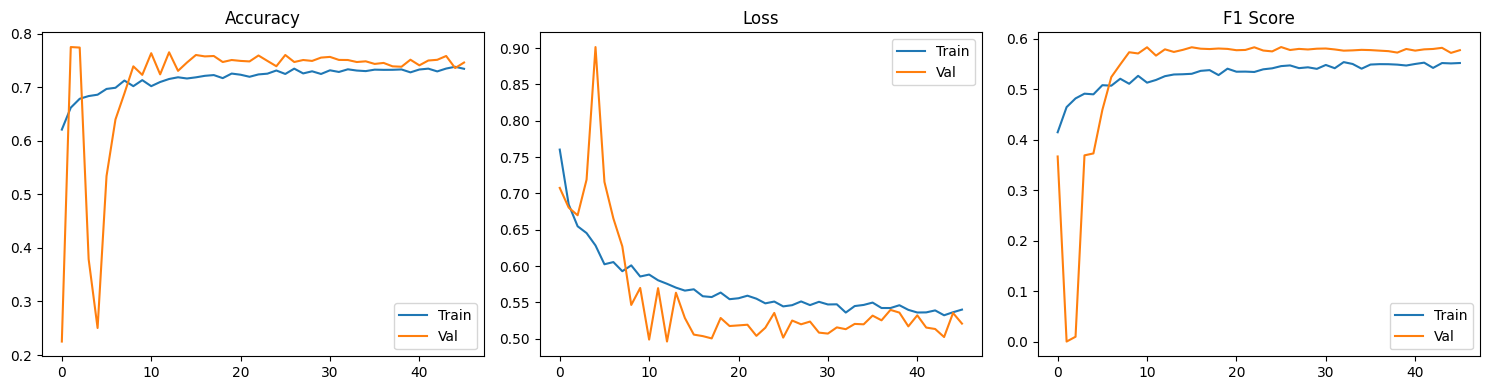

In [136]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(hist.history["accuracy"], label="Train")
plt.plot(hist.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(hist.history["loss"], label="Train")
plt.plot(hist.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(hist.history["f1_score"], label="Train")
plt.plot(hist.history["val_f1_score"], label="Val")
plt.title("F1 Score")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from keras.preprocessing import image
from keras.models import load_model
 
def predict_xray(img_path, model_path="vgg16_pneumonia_best.h5"):
    saved_model = load_model("vgg16_pneumonia_best.keras")
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = np.expand_dims(np.asarray(img) / 255.0, axis=0)
    prob = saved_model.predict(img_array)[0][0]
    label = "PNEUMONIA" if prob > 0.5 else "NORMAL"
    print(f"Prediction : {label}  (confidence: {prob:.2f})")
    return label, prob